In [56]:
# imports
import igraph as ig
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statistics import mode

### Chapter 3 Question 1

First, let's load airport graph:

In [4]:
D = pd.read_csv('connections.csv')
airports = ig.Graph.TupleList([tuple(x) for x in D.values], directed=True, edge_attrs=['weight'])

# add vertex attributes to graph
A = pd.read_csv('airports_loc.csv')
lookup = {k:v for v,k in enumerate(A['airport'])}
l = [lookup[x] for x in airports.vs()['name']]
airports.vs()['layout'] = [(A['lon'][i],A['lat'][i]) for i in l]
airports.vs()['state'] = [A['state'][i] for i in l]
airports.vs()['city'] = [A['city'][i] for i in l]

Build a subgrapf for New York:

In [77]:
NY = airports.subgraph([v for v in airports.vs() if v['state'] == 'NY'])
## drop isolated vertices
NY = NY.subgraph([v for v in NY.vs() if v.degree()>0])

## remove loops
NY = NY.simplify(multiple=False)

For degree centrality, let's use the degree_cantrality function from Chapter 3 notebook, which normalizes the weights to get values bounded above by 1:

In [5]:
# directed degree centrality
def degree_centrality(g, weights=None):
    n = g.vcount()
    if g.is_directed():
        dc = [sum(x)/(2*(n-1)) for x in zip(g.strength(mode='in',weights=weights),\
              g.strength(mode='out',weights=weights))]
    else:
        dc = [x/(n-1) for x in g.strength(weights=weights)]
    return dc

Let's also implement a function that would normalize weights and use them to compute centrality measures (it's usefull to have it as a separate function, because we will focus on centrality measures in questions 3 and 5 as well):

In [11]:
def compute_centrality_measures(g):
    mw = np.max(g.es['weight'])
    g.es()['normalized_weight'] = [w/mw for w in g.es['weight']]

    C = pd.DataFrame({'airport': g.vs()['name'],
                     'degree': degree_centrality(g, weights='normalized_weight'),
                     'pagerank': g.pagerank(weights='weight'),
                     'authority': g.authority_score(weights='weight'),
                     'hub': g.hub_score(weights='weight'),
                     'between': g.betweenness(),
                     'harmonic': g.harmonic_centrality()})
    
    # normalize betweenness
    n = g.vcount()
    C['between'] = [2*x/((n-1)*(n-2)) for x in C['between']]
    
    return C

Compute centrality measures for the airports graph and rank based on degree centrality:

In [80]:
NY_centralities = compute_centrality_measures(NY)

## sort w.r.t. degree centrality, look at top airports
NY_centralities_sorted = NY_centralities.sort_values(by='degree', ascending=False)

In [81]:
NY_centralities_sorted.head()

,airport,degree,pagerank,authority,hub,between,harmonic
0,JFK,0.173125,0.342720,1.000000,0.373760,0.647727,0.791667
2,BUF,0.101629,0.195702,0.261299,1.000000,0.167929,0.791667
4,ROC,0.054908,0.109433,0.141841,0.546989,0.000000,0.708333
5,SYR,0.044959,0.097118,0.113975,0.459400,0.243687,0.833333
1,LGA,0.040011,0.108312,0.213367,0.078989,0.286616,0.833333


New York City's JFK has the highest degree centrality among New York Airports

### Chapter 3 Question 2

Fast Chung-Lu generating function from Chapter 2:

In [49]:
def fastCL(d, m):
    n = len(d)
    s = np.sum(d)
    p = [i/s for i in d]
    target = m
    tples = []
    while len(tples) < target:
        s = target - len(tples)
        e0 = np.random.choice(n, size=s, replace=True, p=p)
        e1 = np.random.choice(n, size=s, replace=True, p=p)
        tples.extend([(min(e0[i],e1[i]),max(e0[i],e1[i])) for i in range(len(e0)) if e0[i]!=e1[i]]) ## ignore loops
        tples = list(set(tples)) ## drop collisions
    return tples

Generate the graph:

In [52]:
n = 10000
gamma = 2.5

delta = 1
Delta = np.sqrt(n)

# generate degrees
W = []
for i in np.arange(1,n+1):
    W.append(delta * (n/(i-1+n/(Delta/delta)**(gamma-1)))**(1/(gamma-1)))

# generate graph with Chung-Lu model
m = int(np.mean(W)*n/2)
tpl = fastCL(W,m)
g = ig.Graph.TupleList(tpl)

Compute centrality measures:

In [60]:
CL_centrality = pd.DataFrame({
        'degree': g.degree(),
        'degree_centrality': degree_centrality(g),
        'pagerank': g.pagerank(),
        'authority': g.authority_score(),
        'hub': g.hub_score(),
        'between': g.betweenness(),
        'harmonic': g.harmonic_centrality()
    })

# normalize betweenness
n = g.vcount()
CL_centrality['between'] = [2*x/((n-1)*(n-2)) for x in CL_centrality['between']]


CL_centrality.sort_values("degree", ascending=False).head()

,degree,degree_centrality,pagerank,authority,hub,between,harmonic
337,94,0.011647,0.002796,0.979209,0.979209,0.055668,0.290303
32,91,0.011275,0.002599,1.000000,1.000000,0.066574,0.294770
54,84,0.010408,0.002459,0.787776,0.787776,0.053569,0.289229
567,82,0.010160,0.002372,0.869845,0.869845,0.051141,0.291280
200,80,0.009912,0.002377,0.579720,0.579720,0.039673,0.277205


Plot average centrality measures for each degree value:

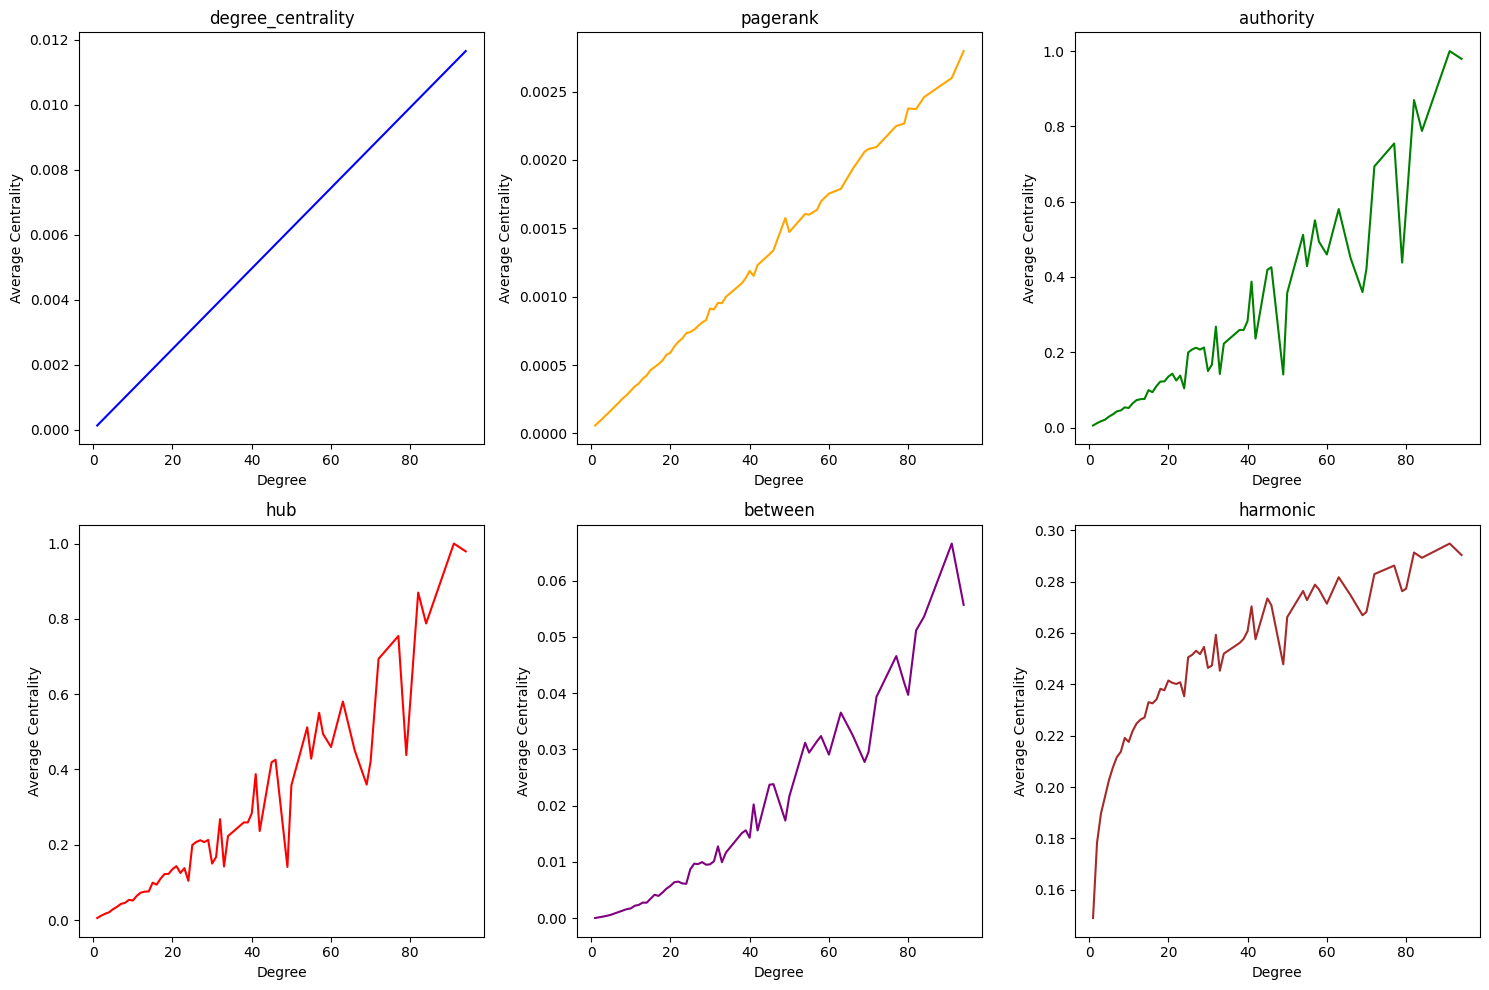

In [74]:
# group by degree and calculate mean for each measure
grouped = CL_centrality.groupby('degree').mean()


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
measures = ['degree_centrality', 'pagerank', 'authority', 'hub', 'between', 'harmonic']
colours = ['blue', 'orange', 'green', 'red', 'purple', 'brown']


for i, (measure, colour) in enumerate(zip(measures, colours)):
    row = i // 3
    col = i % 3
    axes[row, col].plot(grouped.index, grouped[measure], color=colour)
    axes[row, col].set_xlabel('Degree')
    axes[row, col].set_ylabel('Average Centrality')
    axes[row, col].set_title(measure)

plt.tight_layout()
plt.show()

As we can see, Degree centrality and PageRank show the clearest linear correlation with degree, though PageRank maxes out at around 0.0025 and Degree Centrality at around 0.012, which are very small values. Betweenness has a more volatile correlation and also peaks at a relatively small value.

Hub and Authority centralities show strong correlations, and go all the way from 0 to being close to 1 for higher degrees, though volatility for those metrics increases as the degree becomes higher.

Harmonic Centrality has a rapid increase in the beginnig, which then slows down and plateaus around 0.26-0.3.

### Chapter 3 Question 3

First, let's get the conncted graph by removing the 2 nodes:

In [12]:
cl = airports.connected_components(mode='WEAK').membership
giant = mode(cl)
airports_connected = airports.subgraph([v.index for v in airports.vs() if cl[v.index] == giant])

Function to find the minimum number of nodes needed to disconnect the graph when removing nodes in order of their centrality measure (from_top=True for discending order and =False for ascending):

In [25]:
def find_min_nodes_to_disconnect(g, centrality_df, measure, from_top=True):
    # sort nodes by centrality measure and get their indices
    sorted_indices = centrality_df.sort_values(measure, ascending=not from_top).index

    # remove nodes one by one until graph becomes disconnected by looping through the indices
    for i in range(1, len(sorted_indices) + 1):
        nodes_to_remove = sorted_indices[:i]
        temp_g = g.copy()
        temp_g.delete_vertices(nodes_to_remove)
        if len(temp_g.connected_components(mode='WEAK')) > 1:
            return i

    return len(sorted_indices)


Now, for each centrality measure, let's implement the dscribed experiment and print the results:

In [33]:
def centrality_measures_experiment(graph, centrality_measures, measure_name):
    # sort airports by centrality measure
    airports_sorted = centrality_measures[['airport', measure_name]].sort_values(measure_name, ascending=False)
    print(f"Top 5 airports ranked with respect to {measure_name}:\n")
    print(airports_sorted.head())

    # number of of nodes with the largest score that are needed to be removed
    high_count = find_min_nodes_to_disconnect(graph, centrality_measures, measure_name, from_top=True)
    print("\nNumber of nodes with the largest", measure_name,
          "score that are needed to be removed so that the graph is no longer weakly connected: ", high_count)
    
    # number of of nodes with the smallest score that are needed to be removed
    low_count = find_min_nodes_to_disconnect(graph, centrality_measures, measure_name, from_top=False)
    print("Number of nodes with the smallest", measure_name,
          "score that are needed to be removed so that the graph is no longer weakly connected: ", low_count, "\n")

centrality_measures = compute_centrality_measures(airports_connected)
for measure in ['degree', 'pagerank', 'authority', 'hub', 'between', 'harmonic']:
    centrality_measures_experiment(airports_connected, centrality_measures, measure)

Top 5 airports ranked with respect to degree:

   airport    degree
3      ATL  0.053397
9      ORD  0.039726
11     DFW  0.034385
1      LAX  0.029707
10     LAS  0.027510

Number of nodes with the largest degree score that are needed to be removed so that the graph is no longer weakly connected:  2
Number of nodes with the smallest degree score that are needed to be removed so that the graph is no longer weakly connected:  179 

Top 5 airports ranked with respect to pagerank:

   airport  pagerank
3      ATL  0.051320
9      ORD  0.037651
11     DFW  0.035120
1      LAX  0.026628
10     LAS  0.026360

Number of nodes with the largest pagerank score that are needed to be removed so that the graph is no longer weakly connected:  2
Number of nodes with the smallest pagerank score that are needed to be removed so that the graph is no longer weakly connected:  36 

Top 5 airports ranked with respect to authority:

   airport  authority
3      ATL   1.000000
9      ORD   0.837524
1      LA

As we can see, the top 5 ranked airports for degree and page rank are exactly the same, as well as the rankings for authority and hub. Interestingly, Minneapolis airport, which is not in the top 5 for those 4 centrality measures, is the one that has the highest betweenness centrality.

As for how removing high/low ranking nodes affects centrality, Degree, PageRank, authority, and hub measures all need exactly 2 highest-scoring airports removed to disconnect the network; for all of them, the last airport to be removed is Chicago O'Hare International Airport. If we rank airports by harmonic measure, Chicago becomes the highest-ranked airport, and removing only it alone makes the graph disconnected, suggesting the critical role that airports plays for the connectedness of the US airport network. Ranking by betweenness requires the most removals (4) to make the graph disconnected.

When it comes to removing the lowest-scoring airports, hub, betweenness, and harmonic all keep the network connected until the very last airport is removed, suggesting that these metrics are the best at finding truly peripheral nodes (the ones that affect connectedness of the network the least), while pagerank and authority seem to be a bad choice for that task.

### Chapter 3 Question 5

Let's use contract_vertices() function to create a state-to-state graph. Since edge weights represent passenger volumes, it makes sense to combine parallel edges after contraction into a single edge whose weight is the sum of the original edges' weights (_multiple=True_ in the _simplify_ function).

In [35]:
states = list(set(airports.vs['state']))

state_mapping = {v.index: states.index(state) for v, state in zip(airports.vs, airports.vs['state'])}

state_graph = airports.copy()
state_graph.contract_vertices(list(state_mapping.values()))

state_graph.vs['name'] = states
state_graph.simplify(combine_edges='sum', multiple=True, loops=True)

#### (a)

In [38]:
print(state_graph.is_connected(mode='STRONG'))
print(state_graph.is_connected(mode='WEAK'))

True
True


As we can see, the resulting graph is strongly connected.

#### (b)

In [39]:
in_strength = state_graph.strength(mode='in', weights=state_graph.es['weight'])
out_strength = state_graph.strength(mode='out', weights=state_graph.es['weight'])

state_traffic = pd.DataFrame({
    'state': states,
    'incoming_passengers': in_strength,
    'outgoing_passengers': out_strength
})


print("\nTop states by incoming passengers:")
print(state_traffic.sort_values('incoming_passengers', ascending=False).head())

print("\nTop states by outgoing passengers:")
print(state_traffic.sort_values('outgoing_passengers', ascending=False).head())


Top states by incoming passengers:
   state  incoming_passengers  outgoing_passengers
48    CA           44448180.0           44547963.0
44    FL           43267508.0           43161105.0
45    TX           42835438.0           42805475.0
11    GA           35508259.0           35391546.0
27    IL           34304458.0           34299799.0

Top states by outgoing passengers:
   state  incoming_passengers  outgoing_passengers
48    CA           44448180.0           44547963.0
44    FL           43267508.0           43161105.0
45    TX           42835438.0           42805475.0
11    GA           35508259.0           35391546.0
27    IL           34304458.0           34299799.0


The top rankings for outgoing/incoming passengers are very similar, with California being #1 in both.

#### (c)

To get pair of two states, x and y, for which there is the most passengers travelling from x to y, let's first find the heaviest edge and then look at it's source and target states:

In [41]:
max_edge = max(state_graph.es, key=lambda e: e['weight'])
source = state_graph.vs[max_edge.source]['name']
target = state_graph.vs[max_edge.target]['name']
max_passengers = max_edge['weight']

print(f"{source} to {target}: {max_passengers}")

FL to GA: 6584065.0


The buisiest state-to-state direction is from Florida to the State of Georgia, having the volume of 6,584,065 passengers.

#### (d)

Reuse compute_centrality_measures from before (rename airports column to state):

In [47]:
state_centrality = compute_centrality_measures(state_graph).sort_values("degree", ascending=False)
state_centrality = state_centrality.rename(columns={'airport': 'state'})
state_centrality.head()

,state,degree,pagerank,authority,hub,between,harmonic
48,CA,0.135169,0.075945,0.969771,0.971337,0.021798,0.97
44,FL,0.131269,0.073844,1.000000,1.000000,0.025327,0.97
45,TX,0.130073,0.077688,0.925013,0.925349,0.028044,0.99
11,GA,0.107684,0.064350,0.829178,0.827263,0.024180,0.98
27,IL,0.104197,0.063423,0.743696,0.742924,0.037366,1.00


Harmonic centrality values are very close to 1, which is explained by the fact that the graph is strongly connected.